# 03 Préparation des données pour les modèles

Dans le notebook 02, nous avons construit notre cible `score_compromis`. Nous disposons de 666 lignes : 539 pour le développement et 127 réservées au test.

Nous préparons maintenant **les entrées X**, c’est-à-dire la composition et les paramètres de soudage. Nous ne modifions pas la cible et nous ne remplissons pas les mesures mécaniques manquantes pour créer de nouveaux scores.

Nous suivons le TD 1 : observer les valeurs manquantes, choisir les colonnes, remplir les valeurs absentes, encoder les catégories et prévoir la standardisation. Nous utilisons une `Pipeline` pour réappliquer les mêmes traitements.

Nous n’entraînons pas encore de modèle. L’ACP sera réalisée dans le notebook suivant, à partir des données préparées.

## 1 Charger les données du notebook 02

Nous chargeons le fichier qui contient les variables d’entrée, le score et les groupes. Nous reprenons la séparation déjà réalisée : nous ne tirons pas un nouveau test.

`WeldID`, `groupe` et `partition` servent à suivre les observations. Ils ne seront pas des entrées du modèle. UTS et allongement servent à construire la cible : nous les excluons aussi de X.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'outputs/03'
OUT.mkdir(parents=True, exist_ok=True)

# Les fonctions communes sont définies une seule fois dans src/.
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.preparation import creer_preparation

In [2]:
categories = ['AC_DC', 'Electrode_pol', 'WeldType']
donnees = pd.read_csv(
    ROOT / 'outputs/02/dataset_traction.csv', index_col='row_id',
    dtype={c: str for c in categories + ['WeldID', 'partition']},
    keep_default_na=False, na_values=[''], float_precision='round_trip'
)
schema = json.loads((ROOT / 'data/processed/welddb_metadata.json').read_text())['schema']
variables_X = schema['COMPOSITION'] + schema['PROCESS']
X = donnees[variables_X].copy()
y = donnees['score_compromis'].copy()
groupes = donnees['groupe']

assert not set(variables_X) & {'UTS_MPa', 'Elongation_pct', 'score_compromis', 'WeldID', 'groupe'}
assert y.notna().all()

In [3]:
developpement = donnees['partition'] == 'developpement'
test = donnees['partition'] == 'test'
assert (developpement | test).all()
X_dev = X.loc[developpement].copy()
X_test = X.loc[test].copy()
y_dev = y.loc[developpement]
y_test = y.loc[test]
groupes_dev = groupes.loc[developpement]

assert set(groupes_dev).isdisjoint(set(groupes.loc[test]))
print(f'Développement : {len(X_dev)} lignes et {X_dev.shape[1]} entrées.')
print(f'Test réservé : {len(X_test)} lignes.')

Développement : 539 lignes et 30 entrées.
Test réservé : 127 lignes.


## 2 Compter les valeurs manquantes dans les entrées

Nous regardons uniquement le développement. Pour chaque colonne, nous calculons le nombre de valeurs absentes et le pourcentage de valeurs disponibles.

Cela permet de distinguer une colonne presque complète d’une colonne que nous devrions remplir presque entièrement. Nous gardons les lignes ayant des entrées manquantes : nous allons traiter ces absences, plutôt que perdre encore des observations.

In [4]:
completude = pd.DataFrame({
    'valeurs_manquantes': X_dev.isna().sum(),
    'remplissage_pct': 100 * X_dev.notna().mean()
}).sort_values('remplissage_pct')
display(completude.round(1))
completude.to_csv(OUT / 'completude_developpement.csv', index_label='variable')

,valeurs_manquantes,remplissage_pct
As_ppm,500,7.2
Sb_ppm,481,10.8
Sn_ppm,471,12.6
Co,470,12.8
W,470,12.8
B_ppm,344,36.2
Cu,321,40.4
Ni,291,46.0
Mo,286,46.9
Cr,269,50.1


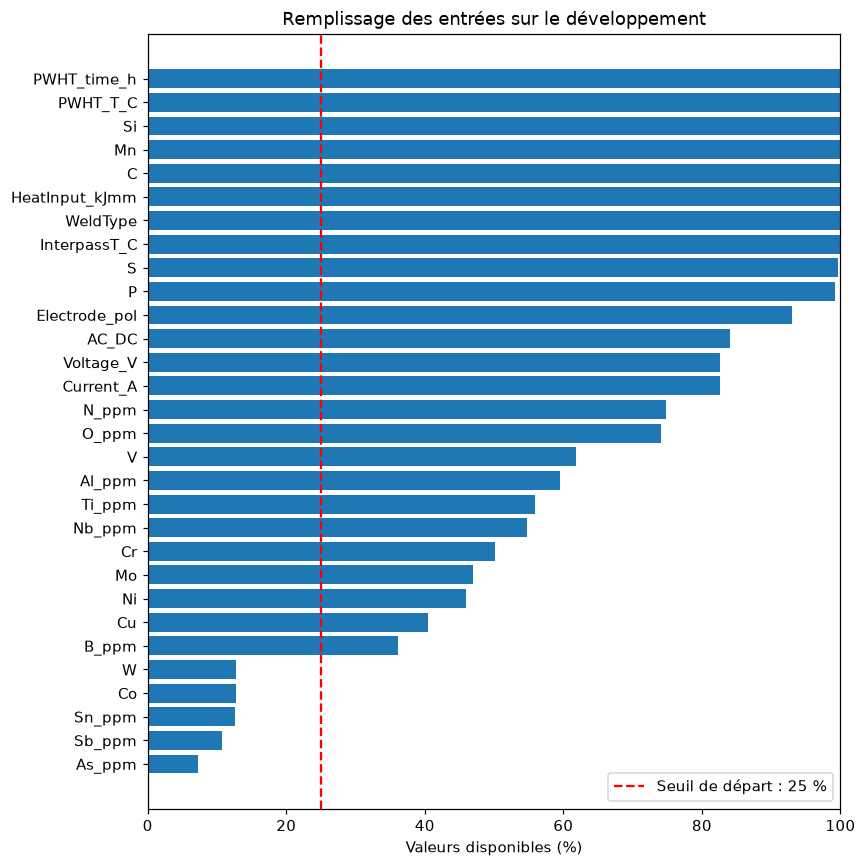

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(completude.index, completude['remplissage_pct'])
ax.axvline(25, color='red', linestyle='--', label='Seuil de départ : 25 %')
ax.set_xlabel('Valeurs disponibles (%)')
ax.set_xlim(0, 100)
ax.set_title('Remplissage des entrées sur le développement')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'completude_entrees.png', dpi=150)
plt.show()

## 3 Choisir les colonnes à conserver

Nous commençons avec un seuil de **25 % de valeurs disponibles**. Cela écarte les colonnes très peu renseignées et conserve davantage de composition chimique qu’un seuil de 50 %.

Ce seuil n’est pas une règle du cours et ne garantit pas que toutes les colonnes conservées seront utiles. Une colonne remplie à 30 % devra encore être imputée à 70 %. Nous comparerons donc ce choix avec d’autres seuils lors de la modélisation.

Le seuil est fixé maintenant ; la liste des colonnes est recalculée sur l’apprentissage de chaque pli de validation. Les colonnes du test ne servent pas à faire ce choix.

In [6]:
SEUIL = 0.25
remplissage = X_dev.notna().mean()
colonnes_gardees = remplissage[remplissage >= SEUIL].index.tolist()
colonnes_ecartees = remplissage[remplissage < SEUIL].index.tolist()

print('Colonnes écartées :', colonnes_ecartees)
print(f'{len(colonnes_gardees)} entrées conservées sur {X_dev.shape[1]}.')
print(f'Nous conservons les {len(X_dev)} lignes de développement.')

Colonnes écartées : ['Co', 'W', 'Sn_ppm', 'As_ppm', 'Sb_ppm']
25 entrées conservées sur 30.
Nous conservons les 539 lignes de développement.


## 4 Choisir comment remplir les valeurs absentes

**Pour les nombres**, nous utilisons la médiane des valeurs présentes dans l’apprentissage. Par exemple, si une concentration manque, nous la remplaçons par la médiane de cette colonne. Ce choix simple ne signifie pas que nous retrouvons la mesure réelle.

**Pour les catégories**, nous ajoutons la valeur `manquant`. Cela évite d’affirmer qu’un procédé absent était forcément le plus fréquent.

Nous gardons les codes existants. En particulier, `0` dans `Electrode_pol` reste une catégorie distincte : sa signification n’est pas assez claire pour la corriger automatiquement. Nous ne fusionnons pas non plus les catégories rares à cette étape.

La médiane est notre méthode de départ. Le cours et le TD 1 présentent aussi l’imputation par régression, à comparer plus tard. Nous n’utiliserons pas le score cible pour remplir les entrées : il ne sera pas connu quand nous prédirons une nouvelle soudure.

In [7]:
# Voir les catégories avant de les encoder.
for colonne in categories:
    print(colonne)
    display(X_dev[colonne].value_counts(dropna=False).to_frame('nombre'))

AC_DC
Electrode_pol
WeldType


,nombre
AC_DC,
DC,446
NaN,86
AC,7


,nombre
Electrode_pol,
+,490
NaN,38
-,6
0,5


,nombre
WeldType,
MMA,380
SA,115
TSA,16
ShMA,7
FCA,6
GTAA,4
GMAA,4
NGSAW,3
SAA,2


## 5 Encoder les catégories et standardiser les nombres

Le `OneHotEncoder` crée des colonnes de 0 et de 1. Par exemple, une colonne peut indiquer si le procédé est MMA. Nous retirons une catégorie de référence par variable, comme dans les exemples du cours, pour éviter des colonnes redondantes.

Si une catégorie nouvelle apparaît plus tard, l’encodeur accepte la ligne et met ses indicateurs à 0. Elle est alors codée comme la catégorie de référence : c’est une limite à garder en tête.

Le `StandardScaler` centre et réduit les colonnes numériques. Cela sera utile pour l’ACP et les méthodes sensibles aux échelles. Pour les arbres et forêts, nous pourrons désactiver cette étape.

La fonction suivante construit ces traitements. `fit` apprend les médianes, les catégories et les paramètres de standardisation sur l’apprentissage. `transform` applique ensuite ces mêmes paramètres aux nouvelles lignes.

Nous utilisons `creer_preparation`, importée depuis `src/preparation.py` : médiane pour les nombres, catégorie « manquant » et one-hot pour les catégories, puis standardisation des nombres. La fonction renvoie aussi les colonnes gardées.

## 6 Observer le résultat sur le développement

Nous ajustons la préparation sur le développement et affichons quelques lignes. Les entrées sont désormais numériques et ne contiennent plus de valeurs manquantes.

Les valeurs centrées et réduites peuvent être négatives : ce n’est pas une concentration négative, mais une valeur située sous la moyenne de la colonne.

Nous ne transformons pas le test ici. Il reste réservé à l’évaluation finale des modèles.

In [8]:
preparation, gardees = creer_preparation(X_dev)
valeurs_preparees = preparation.fit_transform(X_dev)
X_dev_prepare = pd.DataFrame(
    valeurs_preparees, index=X_dev.index,
    columns=preparation.get_feature_names_out()
)

assert len(X_dev_prepare) == len(X_dev)
assert np.isfinite(X_dev_prepare.to_numpy()).all()
print(f'Après préparation : {X_dev_prepare.shape[0]} lignes et {X_dev_prepare.shape[1]} colonnes numériques.')
display(X_dev_prepare.head().round(3))

Après préparation : 539 lignes et 36 colonnes numériques.


,nombres__C,nombres__Si,nombres__Mn,nombres__S,nombres__P,nombres__Ni,nombres__Cr,nombres__Mo,nombres__V,nombres__Cu,nombres__O_ppm,nombres__Ti_ppm,nombres__N_ppm,nombres__Al_ppm,nombres__B_ppm,nombres__Nb_ppm,nombres__Current_A,nombres__Voltage_V,nombres__HeatInput_kJmm,nombres__InterpassT_C,nombres__PWHT_T_C,nombres__PWHT_time_h,categories__AC_DC_DC,categories__AC_DC_manquant,categories__Electrode_pol_-,categories__Electrode_pol_0,categories__Electrode_pol_manquant,categories__WeldType_GMAA,categories__WeldType_GTAA,categories__WeldType_MMA,categories__WeldType_NGGMA,categories__WeldType_NGSAW,categories__WeldType_SA,categories__WeldType_SAA,categories__WeldType_ShMA,categories__WeldType_TSA
row_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-1.689,-0.304,-1.361,-0.223,-0.070,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,-0.344,1.331,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.689,-0.304,-1.361,-0.223,-0.070,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,0.992,-0.637,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.689,-0.231,-0.393,-0.355,0.091,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,-0.344,1.331,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-1.689,-0.231,-0.393,-0.355,0.091,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,0.992,-0.637,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
12,-1.595,-0.159,-1.336,-0.487,-0.151,0.519,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,-0.344,1.331,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Regarder ce que la médiane change

Remplacer des absences par la médiane ajoute plusieurs valeurs identiques dans la distribution. Le graphique ci-dessous le montre sur `Ni`, qui est souvent manquant. L’imputation permet de garder les lignes, mais elle ne reconstitue pas les variations réelles.

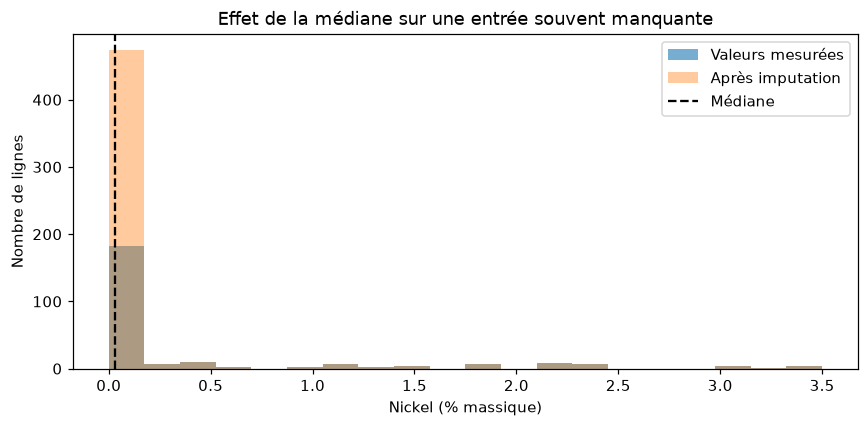

In [9]:
imputation_seule = SimpleImputer(strategy='median')
nickel_rempli = imputation_seule.fit_transform(X_dev[['Ni']]).ravel()
mediane_nickel = imputation_seule.statistics_[0]

fig, ax = plt.subplots(figsize=(8, 4))
bornes = np.histogram_bin_edges(nickel_rempli, bins=20)
ax.hist(X_dev['Ni'].dropna(), bins=bornes, alpha=0.6, label='Valeurs mesurées')
ax.hist(nickel_rempli, bins=bornes, alpha=0.4, label='Après imputation')
ax.axvline(mediane_nickel, color='black', linestyle='--', label='Médiane')
ax.set_xlabel('Nickel (% massique)')
ax.set_ylabel('Nombre de lignes')
ax.set_title('Effet de la médiane sur une entrée souvent manquante')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'imputation_nickel.png', dpi=150)
plt.show()

## 7 Vérifier la préparation dans chaque pli de validation

Pour comparer les modèles, nous utiliserons cinq plis en gardant les groupes séparés. La préparation doit être ajustée à nouveau dans chaque pli : sinon les médianes ou les catégories pourraient utiliser la validation.

La boucle suivante vérifie cette règle, sans entraîner de modèle et sans utiliser le test. Elle accepte que le nombre de colonnes encodées varie selon les catégories présentes dans chaque apprentissage.

Le score exporté par le notebook 02 est calibré sur tout le développement. Pour la future comparaison des modèles, nous reprendrons aussi `plis_cibles` du notebook 02 pour recalculer les cibles dans chaque pli. Ici nous vérifions uniquement X.

In [10]:
validation = GroupKFold(n_splits=5)
verification = []

for numero, (train, val) in enumerate(validation.split(X_dev, groups=groupes_dev), start=1):
    X_train_pli = X_dev.iloc[train]
    X_val_pli = X_dev.iloc[val]
    assert set(groupes_dev.iloc[train]).isdisjoint(set(groupes_dev.iloc[val]))

    preparation_pli, gardees_pli = creer_preparation(X_train_pli)
    train_prepare = preparation_pli.fit_transform(X_train_pli)
    val_prepare = preparation_pli.transform(X_val_pli)
    assert np.isfinite(train_prepare).all() and np.isfinite(val_prepare).all()
    assert train_prepare.shape[1] == val_prepare.shape[1]
    verification.append({'pli': numero, 'lignes_apprentissage': len(train),
                         'lignes_validation': len(val), 'entrees_conservees': len(gardees_pli),
                         'colonnes_apres_encodage': train_prepare.shape[1]})

display(pd.DataFrame(verification))
print('Les 5 plis sont vérifiés. Aucun groupe n’est partagé entre apprentissage et validation.')

Les 5 plis sont vérifiés. Aucun groupe n’est partagé entre apprentissage et validation.


/tmp/ml-notebook-deps/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/tmp/ml-notebook-deps/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,pli,lignes_apprentissage,lignes_validation,entrees_conservees,colonnes_apres_encodage
0,1,431,108,25,36
1,2,431,108,25,35
2,3,431,108,25,36
3,4,431,108,25,36
4,5,432,107,25,35


## 8 Garder une trace pour la suite

Nous enregistrons le tableau préparé du développement et les choix effectués. Ce tableau est utile pour lire les résultats et réaliser une ACP exploratoire sur le développement.

**Pour la validation croisée des modèles, nous repartirons de X non imputé.** Nous reconstruirons la préparation dans chaque apprentissage, au lieu d’utiliser directement le tableau déjà préparé.

Le dataset du notebook 02 conserve toutes les entrées, y compris celles écartées ici. Nous pourrons donc comparer un autre seuil ou une autre imputation sans perdre ces données.

In [11]:
X_dev_prepare.to_csv(OUT / 'X_developpement_prepare.csv', index_label='row_id')
choix = {
    'seuil_remplissage': SEUIL,
    'colonnes_gardees': gardees,
    'colonnes_ecartees': colonnes_ecartees,
    'imputation_numerique': 'mediane',
    'imputation_categorielle': 'categorie manquant',
    'encodage': 'one-hot avec une categorie de reference',
    'standardisation': 'numeriques seulement, ajustee sur apprentissage',
    'dev_row_ids': X_dev.index.tolist(),
    'test_row_ids': X_test.index.tolist(),
    'colonnes_preparees': X_dev_prepare.columns.tolist()
}
(OUT / 'choix_preparation.json').write_text(json.dumps(choix, ensure_ascii=False, indent=2))
print('Résultats enregistrés dans', OUT)

Résultats enregistrés dans /Users/Marie/Documents/projet-soudures/outputs/03


## Conclusion

Nous avons préparé les entrées sans supprimer de nouvelles lignes. Nous avons écarté cinq colonnes très peu renseignées (`As_ppm`, `Sb_ppm`, `Sn_ppm`, `Co`, `W`) et conservé 25 entrées avant encodage.

Nous remplissons les nombres par la médiane et les catégories absentes par `manquant`. Nous encodons les catégories et standardisons les nombres lorsque la méthode le nécessite.

Ces choix sont une première préparation, pas une preuve qu’ils donnent les meilleurs modèles. Nous comparerons ensuite les seuils et, si nécessaire, les méthodes d’imputation sur la validation. Le test reste réservé.

Le prochain notebook portera sur l’ACP : variance expliquée, représentation des observations et interprétation des variables. Nous utiliserons d’abord les entrées numériques standardisées pour éviter de confondre les unités et garder une lecture simple.

Références : cours d’introduction de Myriam Tami, sections sur le prétraitement, et TD 1, parties *Handling missing data*, *Using Pipelines* et *Encoding categorical features*.